### 2.2 完整的动力学系统特征值

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


正在计算方格转移矩阵，看豆子怎么乱跑...
正在抽取该系统的动力学 DNA (特征值)...


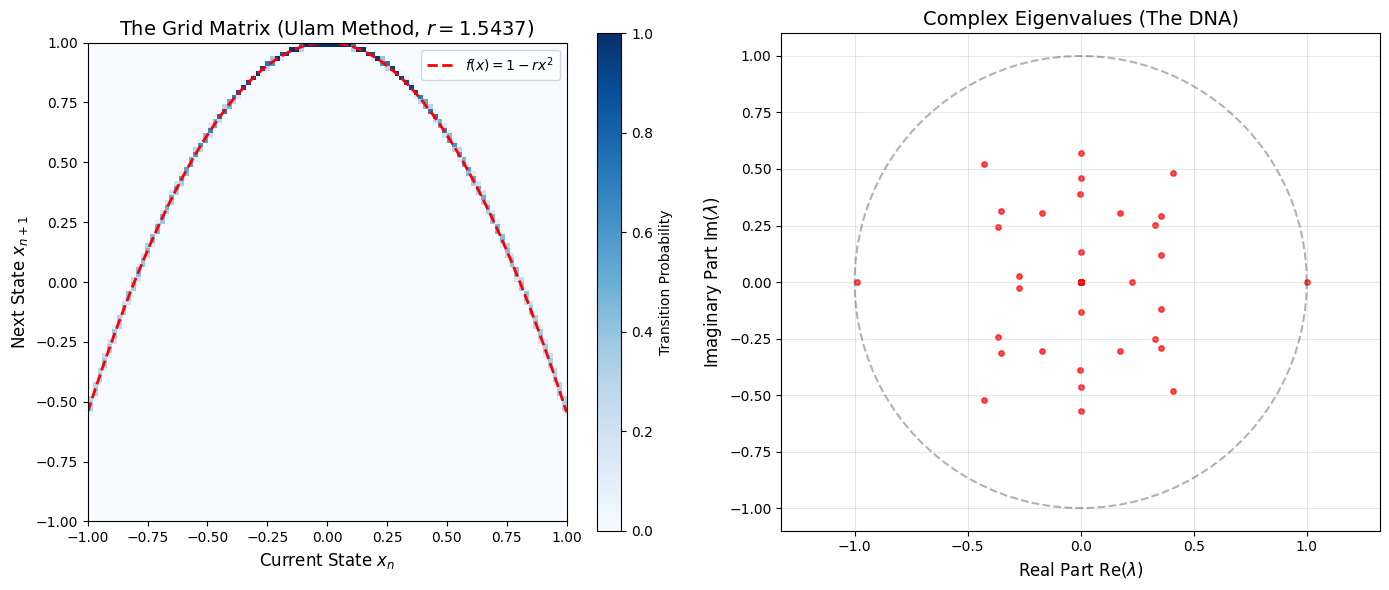

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 步骤 1: 设定物理规则与空间划分
# =====================================================================
r = 1.5437  # 我们的物理参数（老师指定的魔法数字：带合并点的混沌映射）
N = 100     # 把空间切成 100 个方格（设小一点，等下画图才能看清一格一格的像素）

# 用 np.linspace 制造一把尺子，把 [-1, 1] 这个区间切出 101 个刻度
# 这样相邻两个刻度之间，就形成了一个“方格” (Bin)
edges = np.linspace(-1, 1, N + 1)

# 初始化一个 100 x 100 的二维数组，全填 0。
# 这个矩阵 P 就是我们的“账本”，用来记录豆子从哪个方格跳到了哪个方格。
P = np.zeros((N, N))

# =====================================================================
# 步骤 2: 最基础的“撒豆子”法 (无扰动 Ulam 矩阵构造)
# =====================================================================
M = 1000  # 我们在每一个方格里，均匀地撒 1000 颗“虚拟豆子”作为测试

print("正在计算方格转移矩阵，看豆子怎么乱跑...")
# 遍历每一个方格（我们把出发的方格记为 j）
for j in range(N):
    # 1. 确定当前方格的左边界和右边界
    left = edges[j]
    right = edges[j+1]
    
    # 2. 在这个方格里，整整齐齐地摆上 1000 颗豆子
    # x_points 就是这 1000 颗豆子的当前位置
    x_points = np.linspace(left, right, M)
    
    # 3. 让物理定律（也就是我们的公式）发挥作用！
    # 算出每一颗豆子下一步会飞到什么位置
    x_next = 1 - r * (x_points**2)
    
    # 4. 重点来了！清点飞出去的豆子落在了哪些方格里
    # np.histogram 就像一个自动分类机，它会根据 edges 刻度，把 x_next 丢进对应的方格，并数出个数
    counts, _ = np.histogram(x_next, bins=edges)
    
    # 5. 记账：把计数除以总数 M 变成概率，填进账本 P 的第 j 列
    # P[i, j] 的意思就是：从第 j 个方格出发，跳进第 i 个方格的概率是多少
    P[:, j] = counts / M

# =====================================================================
# 步骤 3: 提取灵魂（求解特征值）
# =====================================================================
print("正在抽取该系统的动力学 DNA (特征值)...")
# np.linalg.eigvals 是一把“数学解剖刀”，直接把矩阵内部隐藏的频率和衰减率挖出来
eigvals = np.linalg.eigvals(P)

# =====================================================================
# 步骤 4: 可视化教学（方格矩阵 vs 极点图）
# =====================================================================
plt.figure(figsize=(14, 6))

# --- 左图：把矩阵 P 画出来，看看“方格样式” ---
plt.subplot(1, 2, 1)
# plt.imshow 可以直接把二维数组当成图片显示出来，数值越大颜色越深
plt.imshow(P, cmap='Blues', origin='lower', extent=[-1, 1, -1, 1])
plt.colorbar(label='Transition Probability')
plt.title(rf"The Grid Matrix (Ulam Method, $r={r}$)", fontsize=14)
plt.xlabel(r"Current State $x_n$", fontsize=12)
plt.ylabel(r"Next State $x_{n+1}$", fontsize=12)

# 为了让学生看清物理公式的痕迹，我们把理论上的抛物线也画上去
x_curve = np.linspace(-1, 1, 500)
y_curve = 1 - r * (x_curve**2)
plt.plot(x_curve, y_curve, 'r--', lw=2, label=r'$f(x) = 1 - rx^2$')
plt.legend()

# --- 右图：在复平面上画出特征值 ---
plt.subplot(1, 2, 2)
# 画一个半径为 1 的虚线圆圈（特征值的边界）
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)

# 画出特征值散点
plt.scatter(eigvals.real, eigvals.imag, s=15, c='red', alpha=0.7)

plt.title("Complex Eigenvalues (The DNA)", fontsize=14)
plt.xlabel(r"Real Part Re($\lambda$)", fontsize=12)
plt.ylabel(r"Imaginary Part Im($\lambda$)", fontsize=12)
plt.axis('equal') # 保证 X 轴和 Y 轴比例一致，圆不会被压扁
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 第二课配套讲义

当这两张图出现在大屏幕上时，绝对会引发学生们的惊叹。左边是充满像素感的深蓝色方阵，右边是散落的红色斑点。你可以这样向学生发问并解释：

> **“同学们，欢迎来到第二课。看屏幕左边，这就是计算机理解‘物理世界’的方式——马赛克（方格）。”**

**1. 解码左图：为什么矩阵长得像个抛物线？**
“大家看到左边这张图里深蓝色的像素块了吗？它不是随机的，它完美地勾勒出了一条开口向下的抛物线（红色虚线）。
为什么？因为我们的规则是 。这意味着，如果你在右侧的方格（）出发，你的下一步一定会掉进下方特定的方格里。
**这就是我们在 AI 课里要记住的第一个铁律：所谓的动力学转移矩阵，不过就是把数学方程，拍平成了一张含有概率的二维像素图（方格）。**”

**2. 解码右图：这些红点是什么？**
“再看右边的图。当我们把左边这个包含 100x100 数据的庞大马赛克图丢给 Numpy 的 `eigvals` 函数时，它吐出了 100 个红点。
这些红点，就是这个系统的 **‘隐藏 DNA’（特征值）**。
你们注意到没有？绝大部分红点都挤在圆心（0 点）附近，只有少数几个孤零零地向外扩散。

* **为什么？** 因为我们在算转移概率时，没有任何‘平滑扰动’（噪声），豆子是死板地跳进特定方格的。这导致整个像素图里大部分地方都是白色的（0 概率），包含着大量的死寂和断层。
* **在数学上**，这种没有被噪声‘润滑’过的极度稀疏矩阵，它的特征值会发生**‘坍缩’**，就像冰山碎成了一地冰渣。”

**3. 留给第三课的扣子（呼应终极目标）**
“大家还记得第一节课那个漂亮的、有着强烈排斥感的黎曼目标分布吗？
如果我现在让你们把右图里这些乱七八糟的红点拿去算间距，你们觉得它能符合那个完美的宇宙规律吗？
**绝对不可能！** 它们现在太散碎、太独立了。

所以，我们下一节课的任务，就是化身‘造物主’：**我们要给这个方格矩阵吹入一阵微风（加入高斯扰动 ），看看这些冰渣子是如何在风中融化、重新聚合，最终向着宇宙的真理迈进的！**”

---

王博士，这堂课的代码极度精简，既没有复杂的核函数，也没有高深的归一化，只有最朴素的 `for` 循环和数格子的逻辑。这对于没有任何物理背景的 CS/数学系大一新生来说，是绝佳的认知桥梁！